In [1]:
import sys
import os
from pyspark.sql import SparkSession
import pyspark.sql.functions as s
from pyspark.sql.types import DoubleType, StringType

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = SparkSession.builder \
    .appName("Testing PySpark Example") \
    .master("local[*]") \
    .config("spark.sql.parquet.enableVectorizedReader", "false") \
    .config("spark.driver.memory", "4g")\
    .getOrCreate()

C:\Users\savan\anaconda3\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [2]:
#read in the reduced files

df = spark.read.parquet("2014-2017_DATA", "2018-2026_DATA")

df.printSchema()

root
 |-- VendorID: double (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- PULocationID: double (nullable = true)
 |-- DOLocationID: double (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- trip_duration: double (nullable = true)
 |-- average_trip_speed: double (nullable = true)



In [3]:
total_entries = df.count()
print(total_entries)

180439134


In [4]:
#filter for the correct years of the data set

cleaned_df = df

cleaned_df = cleaned_df.withColumn("year",s.expr("""extract(YEAR from tpep_pickup_datetime)"""))
cleaned_df = cleaned_df.where((s.col("year") > 2013) & (s.col("year") < 2027))
df_entries = cleaned_df.count()
print(df_entries)
cleaned_df = cleaned_df.drop("year")

#trip distance > 0 and trip_distance 

cleaned_df = cleaned_df.where((s.col("trip_distance") > 0)& (s.col("trip_distance") < 20))
df_entries = cleaned_df.count()
print(df_entries)

#passenger_cout > 0  and passenger_count < 5
cleaned_df = cleaned_df.where((s.col("passenger_count") > 0)& (s.col("passenger_count") < 5))
df_entries = cleaned_df.count()
print(df_entries)


#trip duration > 0 hours and trip_duration < 3 hours

cleaned_df = cleaned_df.where((s.col("trip_duration") > 0) & (s.col("trip_duration") < 3))
df_entries = cleaned_df.count()
print(df_entries)

#average trip speed > 0 and less than the speed limit of 55 miles
cleaned_df = cleaned_df.where((s.col("average_trip_speed") > 0) & (s.col("average_trip_speed") < 55))
df_entries = cleaned_df.count()
print(df_entries)

#tip_amount > 0

cleaned_df = cleaned_df.where(s.col("tip_amount") >= 0)
entries_new = cleaned_df.count()
print(entries_new)

#total amount >0 and less than 2000 dollars

cleaned_df = cleaned_df.where((s.col("total_amount") > 0) & (s.col("total_amount") < 2000))
df_entries = cleaned_df.count()
print(df_entries)

#keep only the rows in which the fare amount is less than or equal to 100 dollars.

cleaned_df = cleaned_df.where((s.col("fare_amount") > 0)& (s.col("fare_amount") <= 100))
entries_new = cleaned_df.count()
print(entries_new)

180438663
180417964
167870855
167639904
167472547
167472546
167472535
167472535


In [5]:
#extraction of the min and max ranges from the raw dataset 

min_max_passengers = cleaned_df.select(s.min(s.col("passenger_count")), s.max(s.col("passenger_count")),s.avg(s.col("passenger_count")))
min_max_passengers.show()

trip_distance = cleaned_df.select(s.min(s.col("trip_distance")), s.max(s.col("trip_distance")), s.avg(s.col("trip_distance")))
trip_distance.show()

fare_amount = cleaned_df.select(s.min(s.col("fare_amount")), s.max(s.col("fare_amount")), s.avg(s.col("fare_amount")))
fare_amount.show()

trip_amount = cleaned_df.select(s.min(s.col("tip_amount")), s.max(s.col("tip_amount")), s.avg(s.col("tip_amount")))
trip_amount .show()

total_amount = cleaned_df.select(s.min(s.col("total_amount")), s.max(s.col("total_amount")), s.avg(s.col("total_amount")))
total_amount.show()

trip_duration = cleaned_df.select(s.min(s.col("trip_duration")), s.max(s.col("trip_duration")), s.avg(s.col("trip_duration")))
trip_duration.show()

average_trip_speed = cleaned_df.select(s.min(s.col("average_trip_speed")), s.max(s.col("average_trip_speed")), s.avg(s.col("average_trip_speed")))
average_trip_speed.show()

+--------------------+--------------------+--------------------+
|min(passenger_count)|max(passenger_count)|avg(passenger_count)|
+--------------------+--------------------+--------------------+
|                 1.0|                 4.0|  1.3092430827538377|
+--------------------+--------------------+--------------------+

+------------------+------------------+------------------+
|min(trip_distance)|max(trip_distance)|avg(trip_distance)|
+------------------+------------------+------------------+
|              0.01|             19.99| 2.914266349404415|
+------------------+------------------+------------------+

+----------------+----------------+-----------------+
|min(fare_amount)|max(fare_amount)| avg(fare_amount)|
+----------------+----------------+-----------------+
|            0.01|           100.0|13.46994132512533|
+----------------+----------------+-----------------+

+---------------+---------------+-----------------+
|min(tip_amount)|max(tip_amount)|  avg(tip_amount)|
+--

In [6]:
#check correlations of numerical variables 

from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler

vectors = "correlation_features"
numerical_columns = ["passenger_count", "trip_distance", "fare_amount", "trip_duration", "average_trip_speed", "RatecodeID", "PULocationID", "DOLocationID"]
assembler = VectorAssembler(inputCols = numerical_columns, outputCol = vectors)
vector_df = assembler.transform(cleaned_df).select(vectors)

#obtain correlation matrix

correlation_mat = Correlation.corr(vector_df, vectors)

correlation_mat.collect()[0]['pearson({})'.format(vectors)].values


#"RatecodeID", "PULocationID", "DOLocationID", "payment_type", "fare_amount", "tip_amount", "total_amount", "trip_duration", "average_trip_speed"

array([ 1.        ,  0.02660999,  0.02917998,  0.02926101,  0.00427907,
       -0.02209314, -0.00888283, -0.00718913,  0.02660999,  1.        ,
        0.92885421,  0.78084484,  0.64744154,  0.09353806, -0.09092393,
       -0.10528002,  0.02917998,  0.92885421,  1.        ,  0.85502092,
        0.4796439 ,  0.11485399, -0.08136273, -0.09677626,  0.02926101,
        0.78084484,  0.85502092,  1.        ,  0.15376398,  0.16224625,
       -0.06771697, -0.08453733,  0.00427907,  0.64744154,  0.4796439 ,
        0.15376398,  1.        ,  0.00278561, -0.07091602, -0.07751789,
       -0.02209314,  0.09353806,  0.11485399,  0.16224625,  0.00278561,
        1.        , -0.03044244, -0.02578171, -0.00888283, -0.09092393,
       -0.08136273, -0.06771697, -0.07091602, -0.03044244,  1.        ,
        0.09622824, -0.00718913, -0.10528002, -0.09677626, -0.08453733,
       -0.07751789, -0.02578171,  0.09622824,  1.        ])

C:\Users\savan\anaconda3\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


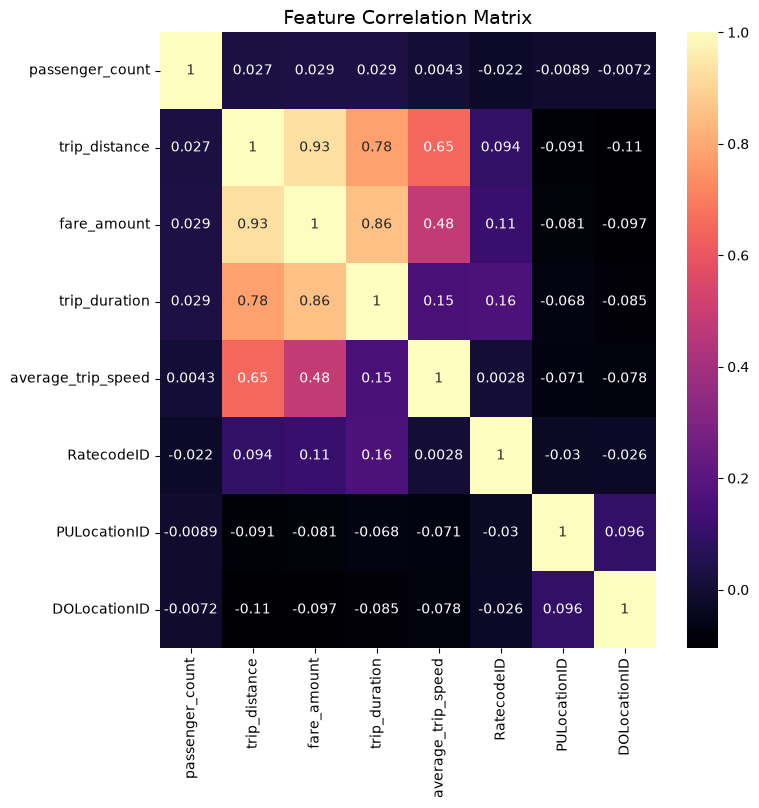

In [7]:
#plot it as a heatmap

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sbn
import numpy as np

correlation_mat_converted = Correlation.corr(vector_df, "correlation_features")
pandas_df =  correlation_mat_converted.toPandas()
matrix_values = pandas_df.iloc[0,0]

matrix_df = pd.DataFrame(matrix_values.toArray(), index = numerical_columns, columns = numerical_columns)

plt.figure(figsize = (8, 8))


sbn.heatmap(matrix_df, annot = True, cmap = "magma")

plt.title("Feature Correlation Matrix", fontsize = 14)

plt.show()

In [8]:
#getting the average tips per year 
#versus the average fare per year

#add a year column to filter by

df = cleaned_df.withColumn("year",s.expr("""extract(YEAR from tpep_pickup_datetime)"""))
df.printSchema()


root
 |-- VendorID: double (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- PULocationID: double (nullable = true)
 |-- DOLocationID: double (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- trip_duration: double (nullable = true)
 |-- average_trip_speed: double (nullable = true)
 |-- year: integer (nullable = true)



In [9]:
#calculate averages per year

average_tips_per_year = df.groupBy("year").agg(s.avg("tip_amount").alias("average_tip_amount")).orderBy("year")

average_tips_per_year.show()

+----+------------------+
|year|average_tip_amount|
+----+------------------+
|2014|1.4783962530259795|
|2015|1.6629587985138212|
|2016|1.7507868428967157|
|2017| 1.789037283143451|
|2018| 1.823744180286124|
|2019| 2.143653296192094|
|2020|2.0653878910343457|
|2021| 2.316248688594344|
|2022|2.6462345996842895|
|2023|3.4917580382150466|
|2024|3.5455950431319225|
|2025|3.6116411432576148|
|2026|3.5626703788744036|
+----+------------------+



C:\Users\savan\anaconda3\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Text(0, 0.5, 'Average tip amount ($)')

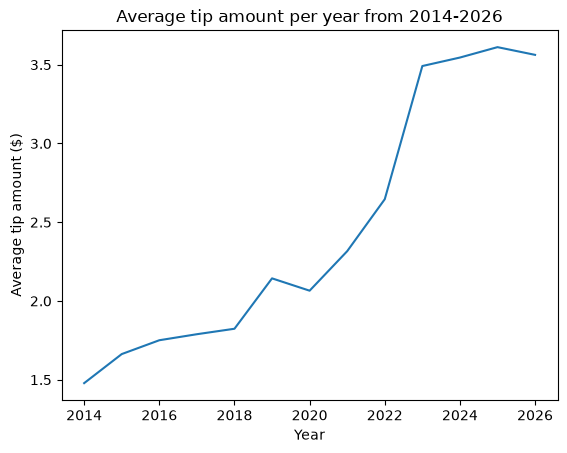

In [10]:
average_tips_per_year_pd = average_tips_per_year.toPandas()

plt.figure()
plt.plot(average_tips_per_year_pd["year"], average_tips_per_year_pd["average_tip_amount"])
plt.title("Average tip amount per year from 2014-2026")
plt.xlabel("Year")
plt.ylabel("Average tip amount ($)")